IEOR 4010E - Lab 1 - Machine Learning
===========================

# Instructions

1. Copy this notebook to your drive (using the "Copy to Drive" button above)
2. Complete the "TODO" portions of this notebook
3. Download the notebook in **.ipynb** format (File -> Download -> Download **.ipynb**)
4. Submit the downloaded **.ipynb** file under the corresponding coding assignments on gradescope.

This lab aims to introduce you to the basics of machine learning using Python and more specifically scikit-learn.

We will cover two methods for classification : Logistic Regression and Gradient Boosted Trees (GBT).

Documentation is available on the following link: [scikit-learn documentation](https://scikit-learn.org/stable/index.html).


# Setup and Dataset

The dataset used for this lab is the cardio-train dataset from Kaggle. It contains various health-related features and a target variable indicating the presence of cardiovascular disease. Our goal is to build models that can predict whether a patient is likely to have cardiovascular disease based on his or her health metrics.

*As this is a known dataset, with models already available on kaggle, any code suspiciously similar to existing solutions will be sanctioned.*

We initially remove the 'ap_hi' feature (which is the patient's systolic blood pressure — the upper value of a blood pressure reading, measured in millimeters of mercury, indicating the pressure in the arteries when the heart contracts), from the dataset and we will add it back later to see its impact.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('cardio_train.csv', sep=';', index_col=0)
df.drop(columns=['ap_hi'], inplace=True)
df.head()

,age,gender,height,weight,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,,,,,,,,,,,
0,18393,2,168,62.0,80,1,1,0,0,1,0
1,20228,1,156,85.0,90,3,1,0,0,1,1
2,18857,1,165,64.0,70,3,1,0,0,0,1
3,17623,2,169,82.0,100,1,1,0,0,1,1
4,17474,1,156,56.0,60,1,1,0,0,0,0


# Logistic Regression

In the first part of the lab, we will manually implement Logistic Regression to classify whether or not a patient has cardiovascular disease.

This implementation will serve as an introduction to the concepts behind Logistic Regression before we use built-in libraries for more complex models.

Logistic Regression is at the heart of Deep Learning models such as Neural Networks, where it is used as the activation function in the output layer for binary classification tasks for example.

## _Question 1_:

a) Implement the logistic regression model using gradient descent. You should complete the functions below. Use the provided dataset to train and evaluate your model. Report:

*   Test accuracy (the proportion of correctly predicted samples out of all samples in the test set)
*   Test loss (the average value of the loss function computed on the test dataset)
*   The confusion matrix





In [2]:
def sigmoid(z):
    """
    Compute the sigmoid function for an array
    """
    return 1 / (1 + np.exp(-z))

def log_loss(y_true, y_pred):
    """
    Compute the logistic loss
    """
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # clip to avoid log(0)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) 
    # y^i corresponds to y_true (the actual labels 0, 1)
    # σ(θ^Τx^i) corresponds to y_pred (the predicted probabilities)
    # 1/m corresponds to the average of all samples (mean)
    return loss


def compute_gradient(X, y, y_pred):
    """
    Compute the gradient of the log loss with respect to weights
    """
    return (X.T @ (y_pred - y)) / len(y)
    # Divide with len(y) to get the average gradient equivalent to 1/m
    # σ(θ^Τx^i) corresponds to y_pred (the predicted probabilities)
    # y is the actual labels vector and corresponds to y^i
    # y_pred - y calculates the the error vector
    # x is the input features x^i
    # The transpose of x (X.T) is used to multiply that with the error vector and performs the summation over all samples

def training(X_train, y_train, X_test, y_test, learning_rate=0.01, n_iterations=1000):
    """
    Train a logistic regression model using gradient descent
    """
    _ , n_features = X_train.shape

    # Initialize weights and bias
    weights = np.zeros(n_features)
    bias = 0

    train_losses = []
    test_losses = []

    for _ in range(n_iterations):
        # Forward pass
        z_train = X_train @ weights + bias
        y_pred_train = sigmoid(z_train)

        # Compute loss
        train_loss = log_loss(y_train, y_pred_train)
        train_losses.append(train_loss)

        # Compute validation loss for plotting purposes
        z_test = X_test @ weights + bias
        y_pred_test = sigmoid(z_test)
        test_loss = log_loss(y_test, y_pred_test)
        test_losses.append(test_loss)

        # Compute gradients
        dw = compute_gradient(X_train, y_train, y_pred_train)
        db = np.mean(y_pred_train - y_train)

        # Update parameters
        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias, train_losses, test_losses

def predict_proba(X, weights, bias):
    """
    Predict probabilities for input samples once the model is trained
    """
    z = X @ weights + bias
    return sigmoid(z)

def predict(X, weights, bias, threshold=0.5):
    """
    Predict 0 or 1 based on a threshold applied to predicted probabilities
    """
    y_pred = predict_proba(X, weights, bias)
    return (y_pred >= threshold).astype(int)
    


In [3]:
# Prepare the data
X = df.drop('cardio', axis=1).values
y = df['cardio'].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale features (important for gradient descent)
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#train the model

learning_rate = 0.1
n_iterations = 1000
weights, bias, train_losses, test_losses = training(X_train_scaled, y_train, X_test_scaled, y_test, learning_rate=learning_rate, n_iterations=n_iterations)

#make predictions on test set
y_pred = predict(X_test_scaled, weights, bias)

#evaluate and print test accuracy and loss function
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Test Loss", test_losses[-1])

# Evaluate confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Cardio', 'Cardio']))



Accuracy:  0.6545714285714286
Test Loss 0.6238509026300079
Confusion Matrix:
[[4788 2200]
 [2636 4376]]

Classification Report:
              precision    recall  f1-score   support

   No Cardio       0.64      0.69      0.66      6988
      Cardio       0.67      0.62      0.64      7012

    accuracy                           0.65     14000
   macro avg       0.66      0.65      0.65     14000
weighted avg       0.66      0.65      0.65     14000



b) Visualize the training and test loss over training iterations and the learned weights for each feature.

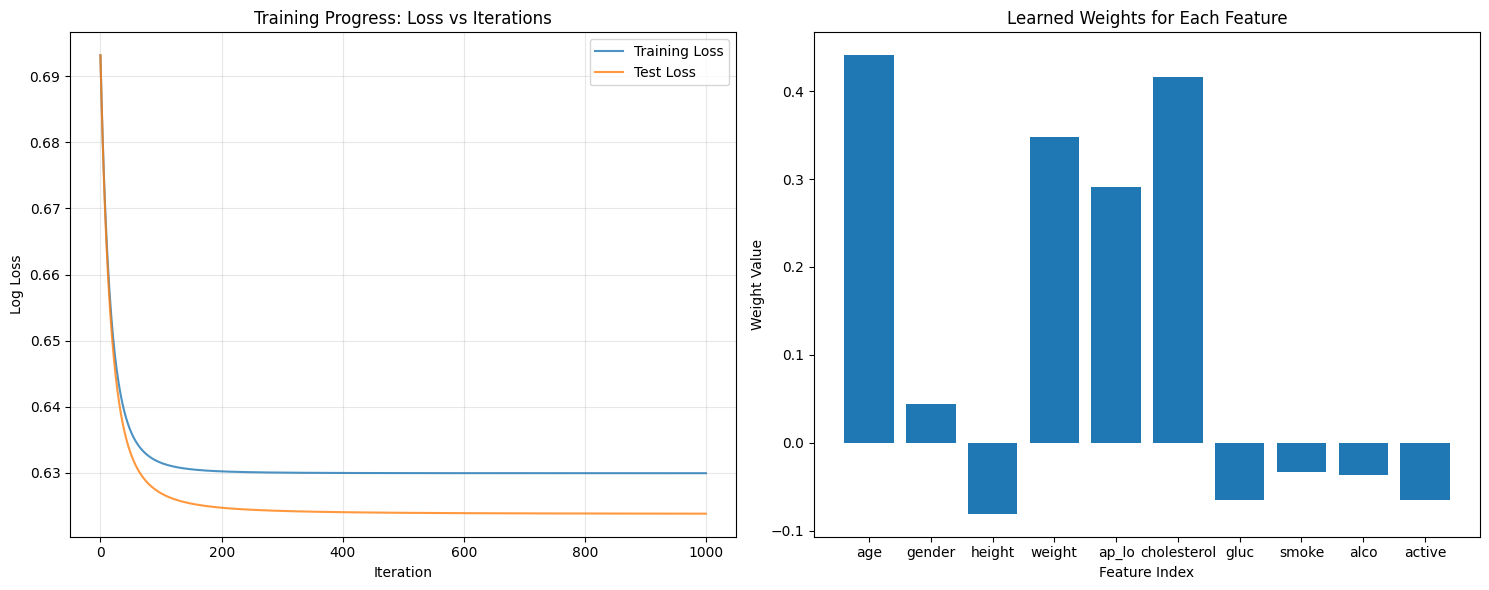

In [8]:
# Visualize training progress

# Requires variables train_losses, test_losses, and weights, which should be the
# outputs of training the model in a)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].plot(train_losses, label='Training Loss', alpha=0.8)
ax[0].plot(test_losses, label='Test Loss', alpha=0.8)
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Log Loss')
ax[0].set_title('Training Progress: Loss vs Iterations')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

#plot a bar chart of the weights
ax[1].bar(df.columns[:-1], weights)
ax[1].set_xlabel('Feature Index')
ax[1].set_ylabel('Weight Value')
ax[1].set_title('Learned Weights for Each Feature')
plt.tight_layout()
plt.show()

## _Question 2_

Now we will add back the 'ap_hi' feature to the dataset and retrain the model. Redo the same steps as the previous questions.

Observe how the weights change, how do they evolve when you increase the number of iterations (to 10000)?

In [40]:
df_full = pd.read_csv('cardio_train.csv', sep=';', index_col=0)
# Prepare the data
X = df_full.drop('cardio', axis=1).values
y = df_full['cardio'].values

# Split the data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model, make predictions on test set, evaluate and print test accuracy)

#scale features (important for gradient descent)
scaler2 = StandardScaler() 
X_train_scaled2 = scaler2.fit_transform(X_train2)
X_test_scaled2 = scaler2.transform(X_test2)

#train the model

learning_rate = 0.1
n_iterations = 1000
weights1, bias1, train_losses, test_losses = training(X_train_scaled2, y_train2, X_test_scaled2, y_test2, learning_rate=learning_rate, n_iterations=n_iterations)

#make predictions on test set
y_pred2 = predict(X_test_scaled2, weights1, bias1)

#evaluate and print test accuracy and loss function
print("Accuracy: ", accuracy_score(y_test2, y_pred2))
print("Test Loss", test_losses[-1])

# Evaluate confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2, target_names=['No Cardio', 'Cardio']))



# for training 10000 iterations


n_iterations = 10000
weights2, bias2, train_losses2, test_losses2 = training(X_train_scaled2, y_train2, X_test_scaled2, y_test2, learning_rate=learning_rate, n_iterations=n_iterations)

#make predictions on test set
y_pred2 = predict(X_test_scaled2, weights2, bias2)

#evaluate and print test accuracy and loss function
print("Accuracy: ", accuracy_score(y_test2, y_pred2))
print("Test Loss", test_losses2[-1])

# Evaluate confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2, target_names=['No Cardio', 'Cardio']))

Accuracy:  0.6760714285714285
Test Loss 0.6075274861408826
Confusion Matrix:
[[4946 2042]
 [2493 4519]]

Classification Report:
              precision    recall  f1-score   support

   No Cardio       0.66      0.71      0.69      6988
      Cardio       0.69      0.64      0.67      7012

    accuracy                           0.68     14000
   macro avg       0.68      0.68      0.68     14000
weighted avg       0.68      0.68      0.68     14000

Accuracy:  0.7190714285714286
Test Loss 0.5795031728423815
Confusion Matrix:
[[5312 1676]
 [2257 4755]]

Classification Report:
              precision    recall  f1-score   support

   No Cardio       0.70      0.76      0.73      6988
      Cardio       0.74      0.68      0.71      7012

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000



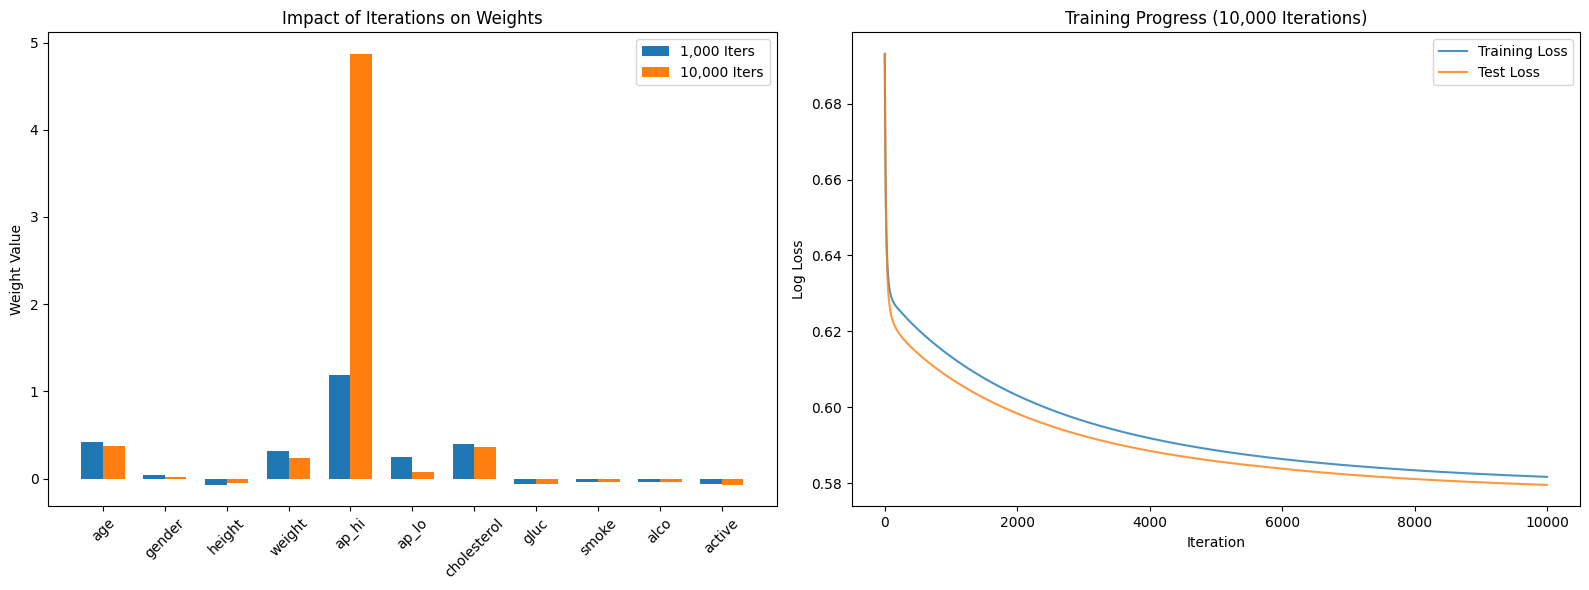

In [41]:
# Visualize the training process and learned weights at two different points n_iterations = 1000 and n_iterations = 10000
# Reuse the plotting code from above

# Create a figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1
features = df_full.columns[:-1]
x = np.arange(len(features))
width = 0.35

# Plot bars for both models
ax[0].bar(x - width/2, weights1, width, label='1,000 Iters')
ax[0].bar(x + width/2, weights2, width, label='10,000 Iters')

ax[0].set_ylabel('Weight Value')
ax[0].set_title('Impact of Iterations on Weights')
ax[0].set_xticks(x)
ax[0].set_xticklabels(features, rotation=45)
ax[0].legend()

# Plot 2
ax[1].plot(train_losses2, label='Training Loss', alpha=0.8)
ax[1].plot(test_losses2, label='Test Loss', alpha=0.8)
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Log Loss')
ax[1].set_title('Training Progress (10,000 Iterations)')
ax[1].legend()

plt.tight_layout()
plt.show()

How do the weights evolve when you increase the number of iterations to 10000?

Overall, the weights remain relatively stable when we increase the number of iterations from 1000 to 10000. An exception is the weight for "ap_hi", which skyrockets when we increase the number of iterations. Because the optimal weight is so large Gradient Descent takes longer to converge to the optimal weight and 1000 iterantions are not enough.

What does this tell you about the importance of the 'ap_hi' feature in predicting cardiovascular disease?

This indicates that the "ap_hi" feature is very important in predicting cardiovascular disease. Most likely this is the most important feature in the model.

Why would we choose to include or exclude this feature based on the weights?

We should include this feature in the model for the reason above. Additionally Accuracy also improved when adding this feature. From 0.65 increased to 0.68-0.72 (depends on the number of iterations). "ap_hi" is also not overfitting the model, based on the test loss and training loss lines which are moving together. Finally, it does not cause data leakage, it is a measurement that can be taken on anyone at a standard check-up.

## _Question 3_ :

Now let's use sk learn to implement logistic regression, using the same dataset as initially (without the 'ap_hi' feature).

In [4]:
# train the model using sklearn's LogisticRegression on the initial dataset
# and compare the learned weights with your implementation
df = pd.read_csv('cardio_train.csv', sep=';', index_col=0)
df.drop(columns=['ap_hi'], inplace=True)

# Prepare the data
X = df.drop('cardio', axis=1).values
y = df['cardio'].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale features (important for gradient descent)
scaler3 = StandardScaler() 
X_train_scaled = scaler3.fit_transform(X_train)
X_test_scaled = scaler3.transform(X_test)

#train the model

logreg = LogisticRegression(penalty='l2', C=1.0)
logreg.fit(X_train_scaled, y_train)

weights_sklearn = logreg.coef_.flatten()
bias_sklearn = logreg.intercept_[0]

#make predictions on test set
y_pred = logreg.predict(X_test_scaled)

#evaluate and print test accuracy and loss function
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Test Loss", test_losses[-1])

# Evaluate confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Cardio', 'Cardio']))

#Compare weights
print("\nManual Weights vs Sklearn Weights:")
for w_manual, w_sk in zip(weights, weights_sklearn):
    print(f"{w_manual:.4f} vs {w_sk:.4f}")


Accuracy:  0.6545714285714286
Test Loss 0.6238509026300079
Confusion Matrix:
[[4790 2198]
 [2638 4374]]

Classification Report:
              precision    recall  f1-score   support

   No Cardio       0.64      0.69      0.66      6988
      Cardio       0.67      0.62      0.64      7012

    accuracy                           0.65     14000
   macro avg       0.66      0.65      0.65     14000
weighted avg       0.66      0.65      0.65     14000


Manual Weights vs Sklearn Weights:
0.4407 vs 0.4406
0.0447 vs 0.0452
-0.0805 vs -0.0808
0.3472 vs 0.3471
0.2914 vs 0.2944
0.4155 vs 0.4157
-0.0649 vs -0.0651
-0.0330 vs -0.0333
-0.0371 vs -0.0369
-0.0647 vs -0.0647


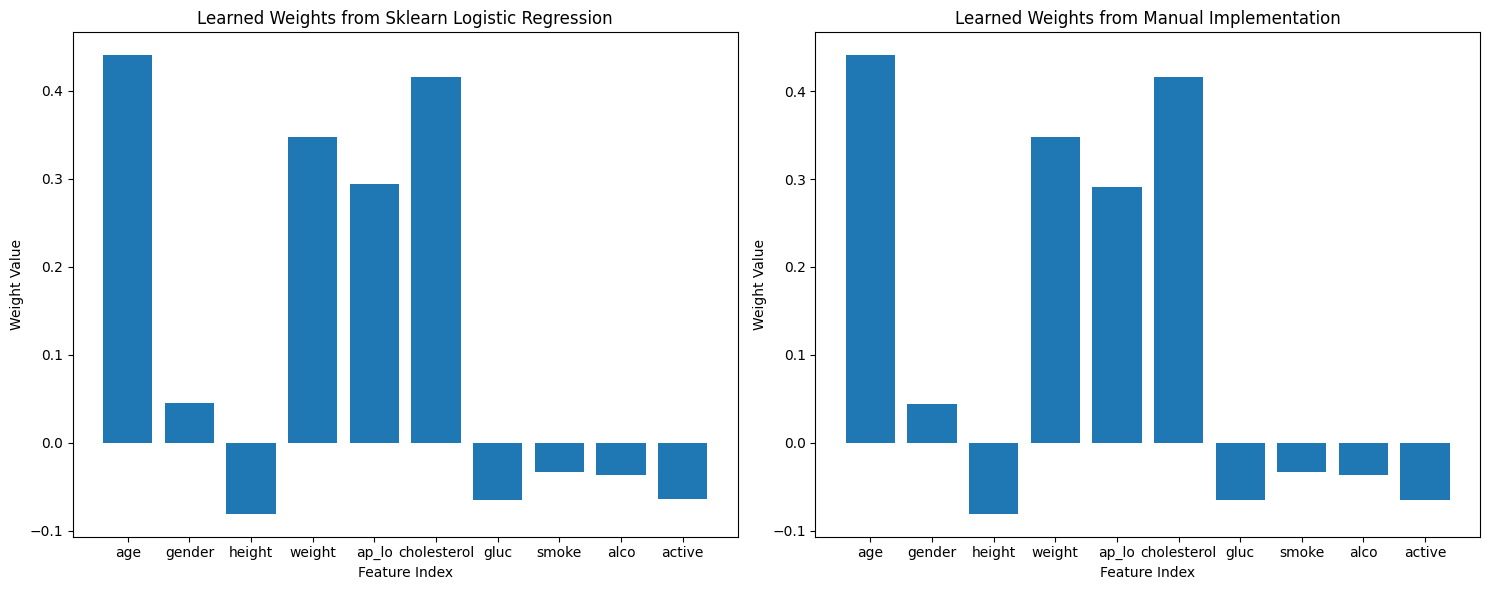

In [10]:

# plot a bar chart of the weights from sklearn and compare with our implementation
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# plot a bar chart of the weights from sklearn
ax[0].bar(df.columns[:-1], weights_sklearn)
ax[0].set_xlabel('Feature Index')
ax[0].set_ylabel('Weight Value')
ax[0].set_title('Learned Weights from Sklearn Logistic Regression')

# pot a bar chart of the weights from our implementation
ax[1].bar(df.columns[:-1], weights)
ax[1].set_xlabel('Feature Index')
ax[1].set_ylabel('Weight Value')
ax[1].set_title('Learned Weights from Manual Implementation')
plt.tight_layout()
plt.show()

Compare the weights obtained from your manual implementation with those from sklearn's LogisticRegression. Are they similar?

The manual calculated weights and the sklearn calculated weights are very similar. That's expected since both models are solving the same optimization problem, with enough iterations. There are some small differences caused by the use o different solvers. Manually, we used gradient descent but sklearn uses a more sophisticated solver. Also sklearn applies L2 regularization by default (c=1.0), which I did not include in my manual calculations.

# Gradient Boosting Machines (GBMs)

We will now focus on implementing a Gradient Boosting Machine using SK learn and weak decision trees.

## _Question 1_ :

Most of the pipeline is automated by the package, but we can choose the loss, either ```log_loss``` (default, the same as the logistic loss) or ```exponential```

In [5]:
from sklearn.ensemble import GradientBoostingClassifier
# train two models over X_train, y_train, using the imported GradientBoostingClassifier, one with the log loss and
# one with exponential loss, and the following parameters: n_estimators=100
# learning_rate=0.1, max_depth=5, max_leaf_nodes=15, loss='log_loss', random_state=10027

modelone = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, max_leaf_nodes=15, loss='log_loss', random_state=10027)
modeltwo = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, max_leaf_nodes=15, loss='exponential', random_state=10027)

modelone.fit(X_train, y_train)
modeltwo.fit(X_train, y_train)

# print the test accuracy of each model
print("Model 1 accuracy:", modelone.score(X_test, y_test))
print("Model 2 accuracy:", modeltwo.score(X_test, y_test))

Model 1 accuracy: 0.7072142857142857
Model 2 accuracy: 0.7083571428571429


## _Question 2_ :
We are looking for the optimal learning rate for the Gradient Boosting Classifier. Using cross-validation, find the best value of this hyper-parameter and the corresponding test accuracy. Use seed 10027 for reproducibility of the data splits.

In [6]:
import warnings
warnings.filterwarnings('ignore', message='pkg_resources is deprecated')
# hyperparameter tuning to find the best parameters for the GBM model
# using GridSearchCV from sklearn
from sklearn.model_selection import GridSearchCV, StratifiedKFold

learning_rates = [0.01, 0.05, 0.1, 0.15, 0.2, 0.5]

#cross-validation with SK learn's GridSearchCV

param_grid = {"learning_rate": learning_rates}

modeltwo = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, max_leaf_nodes=15, loss='exponential', random_state=10027)

grid_search = GridSearchCV(
    modeltwo,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10027),
    scoring="accuracy",
    n_jobs=-1
)

# Run the search
grid_search.fit(X_train, y_train)

best_lr = grid_search.best_params_["learning_rate"]

# Evaluate based on accuracy

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test = accuracy_score(y_test, y_pred)

#print the best learning rate and corresponding test accuracy.

print("Best learning_rate:", best_lr)
print("Test accuracy:", test)

Best learning_rate: 0.15
Test accuracy: 0.7072857142857143


## _Question 3_ :
Based on your findings from the two previous sections, which model would you choose for this classification task and why ? Consider factors such as interpretability, performance, training time, and ease of implementation in your answer.

Both models perform equally. The model two which is using exponential loss is slightle better in terms of accuracy. 0.708 over 0.707 and after tuning it in Question 2 is 0.707. The difference is minimal but consistently better or equal and that is why model two was selected for Question 2. In terms of intepretability both models anre GBMs and have similar structure. We use the same parameters to train (number of trees, depth) so there is no difference in terms of trainining time. Finally, both are relative easy to implement. Either model could be chosen for this classification task, I chose the second (exponentail loss) based on the slighltly better perfromance.

### **Remarks**:

While we have used sk learn to do everything under the hood in the library, GBMs are available in many other libraries such as XGBoost, LightGBM or CatBoost, which are optimized for speed and performance.

XGBoost in particular is widely used in industry and competitive machine learning due to its efficiency and accuracy. The principle between the two stays the same, XGBoost and GradientBoostingClassifier both build trees sequentially where each tree corrects the errors of the previous ones, but XGBoost adds L1/L2 regularization to the loss function, uses a more sophisticated split-finding algorithm, handles missing values natively, and it's speed is optimized through parallel processing and cache awareness (supports GPU training as well)

 Feel free to experiment with these libraries if you have time, for example using XGBoost's XGBClassifier below and compare the results with sklearn's GradientBoostingClassifier. If you really want to go the extra mile, you can also try to implement a simple version of gradient boosting from scratch, similar to what we did for logistic regression earlier.

# From Predictions to Decisions

Now let's experiment the tradeoffs and decision making by comparing the performance of the model and finding the optimal decision threshold for classification.

## _Question 1_

In order to make decision on the threshold to use for classification, we need to consider two things, the performance of the model for different thresholds, and the cost associated with false positives and false negatives, to weigh the two accordingly and find the optimal threshold for prediction.

Using your logistic regression model trained over the full dataset, plot the ROC curve for the model on the test set. Calculate the AUC for the ROC curve.

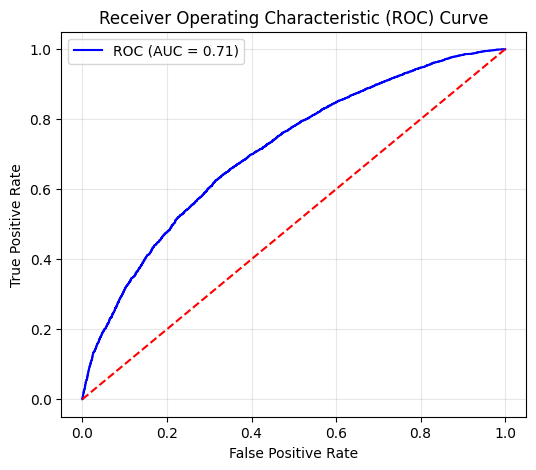

In [ ]:
from sklearn.metrics import roc_curve, auc

# compute the predicted probabilities p of your logistic regression model
# for the scaled test set
y_proba = predict_proba(X_test_scaled, weights_sklearn, bias_sklearn)

# compute the ROC curve and AUC for the model predictions on the test set
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='blue', label=f'ROC (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='red', linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend()
ax.grid(True, alpha=0.3)


plt.show()

## _Question 2_

For this question, you must first complete Q1 on the written ML assignment.
Building on this question from the written hw and your answer to it, the goal is
to find the best classification threshold $\tau$ for the scenario where the
hospital would be trying to minimize the average cost per patient.

To find the optimal threshold, we iterate over different thresholds and calculate the average cost per patient if the classification model would use this particular threshold to give a final prediction about whether a patient has a predisposition to a cardiovascular disease or not, using the predicted probabilities from your logistic regression model.

23026.431198000002
17487.8157933736
Optimal Decision Threshold: 0.2626
Minimum Expected Cost per Patient Screened: $9695.67


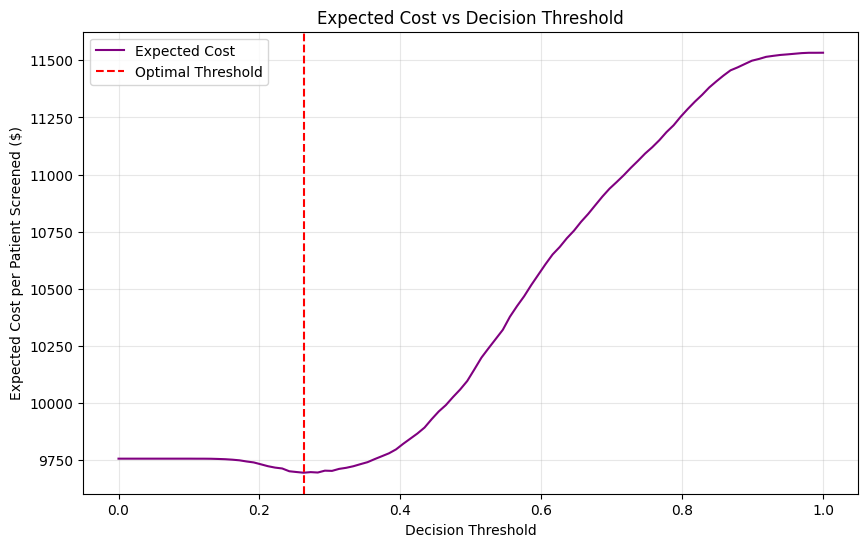

In [28]:
def false_negative_cost():
    total_cost = 0
    for k in range(1, 11):  # years 1 to 10
        prob_incident_k = (0.9 ** (k - 1)) * 0.1
        cost_if_incident = 30000 + 1000 * (10 - k)
        total_cost += prob_incident_k * cost_if_incident
    return total_cost

C_FN = false_negative_cost()

C_FP = 2000
C_TP = (1-(1-0.02)**10)*30000+2000+1000*10
C_TN = 0

print(C_FN)
print(C_TP)

def average_cost_at_threshold(threshold, y_true, y_proba, C_FP, C_FN, C_TP, C_TN):
    """
    Calculate the average cost per patient screened given a decision threshold
    """
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Calculate average cost
    average_cost = (C_FP*fp + C_FN*fn + C_TP*tp + C_TN*tn) / len(y_true)
    return average_cost

# optimal threshold search
thresholds_to_evaluate = np.linspace(0, 1, 100)
costs = []
for thresh in thresholds_to_evaluate:
    cost = average_cost_at_threshold(thresh, y_test, y_proba, C_FP, C_FN, C_TP, C_TN)
    costs.append(cost)

# find optimal threshold that minimizes average cost
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds_to_evaluate[optimal_idx]
min_cost = costs[optimal_idx]

print(f"Optimal Decision Threshold: {optimal_threshold:.4f}")
print(f"Minimum Expected Cost per Patient Screened: ${min_cost:.2f}")

# Plot Expected Cost vs Decision Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_to_evaluate, costs, label='Expected Cost', color='purple')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Expected Cost per Patient Screened ($)')
plt.title('Expected Cost vs Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## _Question 4_

Let's know suppose the price of the treatment goes up to \$2000 per year due to increased healthcare costs. Recalculate the expected costs for each of the four outcomes (TP, FP, TN, FN) and determine the new optimal decision threshold for our model. How does this change impact our decision-making process compared to the previous scenario? What is happening ?

26513.215599000006
27487.8157933736
Optimal Decision Threshold: 1.0000
Minimum Expected Cost per Patient Screened: $13279.48


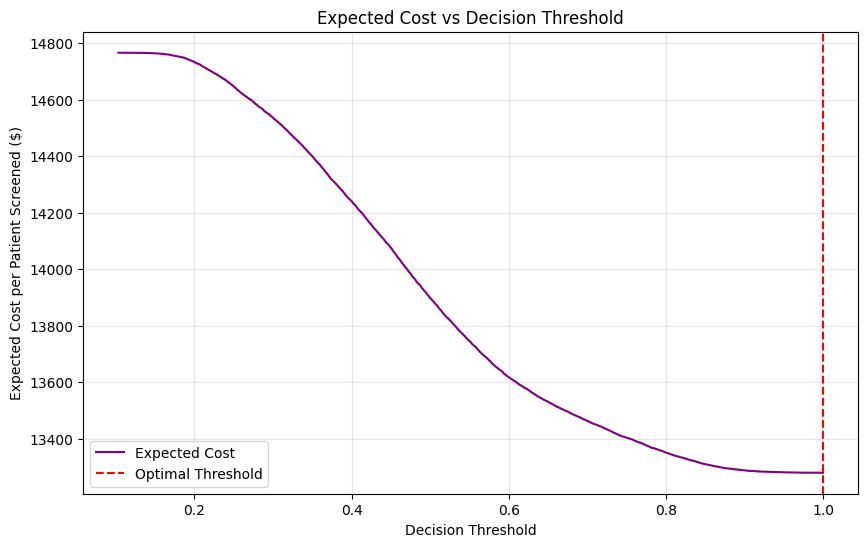

In [ ]:
# TODO
# calculate and print the new costs for the four situations

def false_negative_cost():
    total_cost = 0
    for k in range(1, 11):  # years 1 to 10
        prob_incident_k = (0.9 ** (k - 1)) * 0.1
        cost_if_incident = 30000 + 2000 * (10 - k)
        total_cost += prob_incident_k * cost_if_incident
    return total_cost

C_FN = false_negative_cost()

C_FP = 2000
C_TP = (1-(1-0.02)**10)*30000+2000+2000*10
C_TN = 0

print(C_FN)
print(C_TP)

def average_cost_at_threshold(threshold, y_true, y_proba, C_FP, C_FN, C_TP, C_TN):
    """
    Calculate the average cost per patient screened given a decision threshold
    """
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Calculate average cost
    average_cost = (C_FP*fp + C_FN*fn + C_TP*tp + C_TN*tn) / len(y_true)
    return average_cost

# optimal threshold search
thresholds_to_evaluate = np.linspace(0, 1, 100)

costs = []
for thresh in thresholds_to_evaluate:
    cost = average_cost_at_threshold(thresh, y_test, y_proba, C_FP, C_FN, C_TP, C_TN)
    costs.append(cost)

# find optimal threshold that minimizes average cost
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds_to_evaluate[optimal_idx]
min_cost = costs[optimal_idx]

print(f"Optimal Decision Threshold: {optimal_threshold:.4f}")
print(f"Minimum Expected Cost per Patient Screened: ${min_cost:.2f}")

# Plot Expected Cost vs Decision Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_to_evaluate, costs, label='Expected Cost', color='purple')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Expected Cost per Patient Screened ($)')
plt.title('Expected Cost vs Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## _Question 5_

Going back to the initial costs, what are some assumptions made in this analysis that could impact the decision-making process? In a real-world scenario, what should the hospital be optimizing for, in addition to minimizing average dollar cost per patient?

There are several assumptions made that could impact the decision-making process: 
1. Each patient who has predisposition and is tested positive and takes the treatment could have more than one incidents over the 10 years.
2. The medical test cannot be 100% accurate.
3. Patients who have the predispotion according to the ML model possibly they did not follow up with the medical test.
4. Patients who tested positive by the medical test maybe never received treatment.
5. The treatment in the 10 years could be interrupted, someone gave up.
6. The treatment may not be effective for some patients.
7. The probabilities vary per patient and depend also on other characteristics.
8. The ML model must be applied to the whole target population, selection bias must be avoided.
9. There may be capacity constraints in the hospital for testing and treatments.

The hospital besides the average cost should optimize over the patient outcomes. How many prevented incidents, what is the mortality rate and how helpful is the treatment? The model also should be optimized in terms of fairness and equity. That the performance for all population groups is similar.

# Support Vector Machines (SVM) : Optional

SVMs are another model class for classification, in addition to linear models, decision trees, and GBMs, which we did not cover in class. They are powerful classifiers that work well on smaller datasets and can handle non-linear decision boundaries using kernel functions. If you would like to learn about SVMs on your own, test them on this cardiovascular disease dataset, and compare their performances to linear regression and GBMs, we have added this optional part of the assignment for you. We emphasize that this part is completely optional and will not be graded.

The goal here is to try out the different kernels that SVMs implementations offer (this lab compares linear, polynomial, radial basis function but more exist) and see how they affect the model's performance on the dataset. Please be wary that training time for the SVM (especially Gaussian on a CPU) can be quite long on larger datasets as it is is between a $ O(n^2)$ and $O(n^3)$ operation.

**Optional** For those with a Nvidia GPU, consider using cuML's SVM implementation for faster training times that handles the parallelization of the kernel calculation, simply use ```from cuml.svm import SVC``` instead of ```from sklearn.svm import SVC``` For installation instructions, use your favorite ai chatbot as it depends on your Cuda version. You are left to your own devices but can gain significant speedups on larger datasets and experiment with cuda features. (The linear kernel might still take a bit of time)

## _Question 1_  

Implement a function to train and evaluate a SVM with the kernel specified as a parameter, and run it with an rbf kernel

In [7]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, svm_pred))

# Evaluate confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=['No Cardio', 'Cardio']))

Accuracy:  0.6033571428571428
Confusion Matrix:
[[4522 2466]
 [3087 3925]]

Classification Report:
              precision    recall  f1-score   support

   No Cardio       0.59      0.65      0.62      6988
      Cardio       0.61      0.56      0.59      7012

    accuracy                           0.60     14000
   macro avg       0.60      0.60      0.60     14000
weighted avg       0.60      0.60      0.60     14000



## _Question 2_

Run the code with a linear and sigmoid kernel, and compare the results (plot the accuracy comparison)

In [8]:
import matplotlib.pyplot as plt

svm_model2 = SVC(kernel='linear', C=1.0, random_state=42)
svm_model2.fit(X_train, y_train)

svm_pred2 = svm_model2.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, svm_pred2))

# Evaluate confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred2))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred2, target_names=['No Cardio', 'Cardio']))

svm_model3 = SVC(kernel='sigmoid', C=1.0, random_state=42)
svm_model3.fit(X_train, y_train)

svm_pred3 = svm_model3.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, svm_pred3))


Accuracy:  0.6508571428571429
Confusion Matrix:
[[4518 2470]
 [2418 4594]]

Classification Report:
              precision    recall  f1-score   support

   No Cardio       0.65      0.65      0.65      6988
      Cardio       0.65      0.66      0.65      7012

    accuracy                           0.65     14000
   macro avg       0.65      0.65      0.65     14000
weighted avg       0.65      0.65      0.65     14000

Accuracy:  0.4039285714285714


Confusion Matrix:
[[2866 4122]
 [4223 2789]]

Classification Report:
              precision    recall  f1-score   support

   No Cardio       0.40      0.41      0.41      6988
      Cardio       0.40      0.40      0.40      7012

    accuracy                           0.40     14000
   macro avg       0.40      0.40      0.40     14000
weighted avg       0.40      0.40      0.40     14000



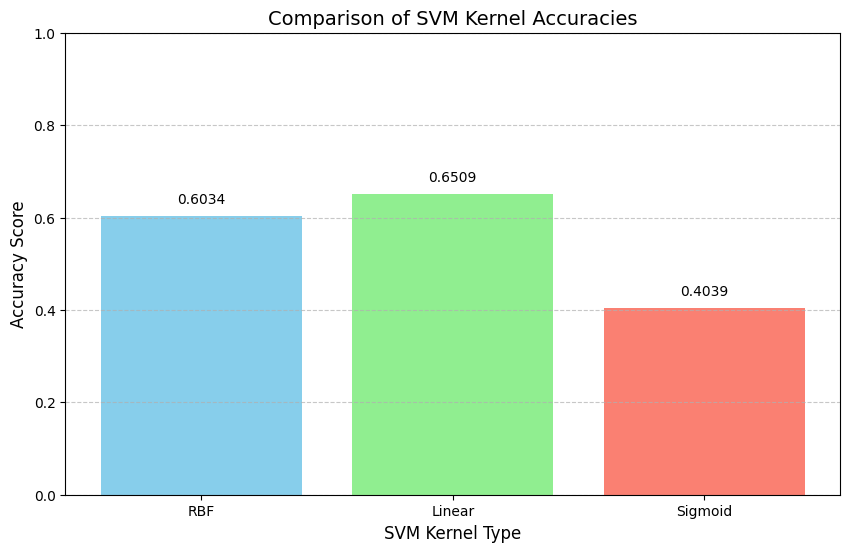

In [9]:
# Evaluate confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred3))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred3, target_names=['No Cardio', 'Cardio']))


# 1. Gather all accuracy scores 
accuracies = {
    'RBF': accuracy_score(y_test, svm_pred),     # From Q1
    'Linear': accuracy_score(y_test, svm_pred2),  # From Q2 linear
    'Sigmoid': accuracy_score(y_test, svm_pred3)  # From Q2 Sigmoid
}

# 2. Create the Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'lightgreen', 'salmon'])

# 3. Add Labels and Title
plt.xlabel('SVM Kernel Type', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Comparison of SVM Kernel Accuracies', fontsize=14)
plt.ylim(0, 1.0) # Accuracy is between 0 and 1

# 4. Add accuracy labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()